# Nassau Candy Distributor — Factory Reallocation & Shipping Optimization
### EDA, Modeling, and Recommendation Engine

This notebook walks through the full pipeline: data cleaning, exploratory
analysis, feature engineering, model training/evaluation, and the
optimization logic that generates factory reassignment recommendations.

**Sections:**
1. Setup & Data Loading
2. Data Quality Investigation (corrupted date fields)
3. Feature Engineering
4. Exploratory Data Analysis
5. Model Training & Evaluation
6. Model Evaluation Visuals
7. Optimization Logic
8. Recommendation Results


In [14]:
import sys
sys.path.insert(0, '../src')

import math
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
pd.set_option('display.max_columns', 50)

## 1. Setup & Data Loading

In [15]:
df_raw = pd.read_csv('../data/Nassau_Candy_Distributor.csv')
print(df_raw.shape)
df_raw.head()

(10194, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [16]:
df_raw.dtypes

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

In [17]:
df_raw.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

## 2. Data Quality Investigation

Before computing lead time, we check whether `Order Date` and `Ship Date`
are trustworthy.

In [19]:
df_raw['OrderDate'] = pd.to_datetime(df_raw['Order Date'], format='%d-%m-%Y')
df_raw['ShipDate'] = pd.to_datetime(df_raw['Ship Date'], format='%d-%m-%Y')
naive_lead_time = (df_raw['ShipDate'] - df_raw['OrderDate']).dt.days

print('Naive lead time stats (days):')
print(naive_lead_time.describe())
print()
print('Order Date range:', df_raw['OrderDate'].min().date(), '-', df_raw['OrderDate'].max().date())
print('Ship Date range:', df_raw['ShipDate'].min().date(), '-', df_raw['ShipDate'].max().date())
print('Order ID year prefixes:')
print(df_raw['Order ID'].str[:7].value_counts())

Naive lead time stats (days):
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
dtype: float64

Order Date range: 2024-01-02 - 2025-12-31
Ship Date range: 2026-06-30 - 2030-06-28
Order ID year prefixes:
Order ID
US-2024    3312
US-2023    2587
US-2022    2102
US-2021    1993
CA-2024      67
CA-2021      58
CA-2023      47
CA-2022      28
Name: count, dtype: int64


**Finding:** naive lead time averages ~1,320 days (3.6 years) — clearly
not real. Order IDs carry year prefixes 2021-2024, Order Date spans only
2024-2025, and Ship Date spans 2026-2030: three inconsistent timelines.
This is consistent with a public retail dataset ("Superstore") whose date
fields were re-randomized for this assignment.

**Decision:** use Ship Mode as the ground-truth speed proxy instead, combined
with a disclosed distance-based transit-time assumption (see Section 3).

## 3. Feature Engineering

In [20]:
from reference_data import (
    FACTORIES, PRODUCT_FACTORY, PRODUCT_DIVISION, STATE_CENTROIDS,
    SHIP_MODE_LEAD_DAYS, MILES_PER_EXTRA_DAY, SHIPPING_COST_PER_UNIT_PER_100_MILES,
)

def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlambda/2)**2
    return 2 * R * math.asin(math.sqrt(a))

df = df_raw.copy()
df['Product Name'] = df['Product Name'].str.strip()
df['Factory'] = df['Product Name'].map(PRODUCT_FACTORY)
df['Division_clean'] = df['Product Name'].map(PRODUCT_DIVISION)
df['LeadTimeProxyDays'] = df['Ship Mode'].map(SHIP_MODE_LEAD_DAYS)
df['ProfitMargin'] = df['Gross Profit'] / df['Sales'].replace(0, pd.NA)

df['cust_lat'] = df['State/Province'].map(lambda s: STATE_CENTROIDS.get(s, (None, None))[0])
df['cust_lon'] = df['State/Province'].map(lambda s: STATE_CENTROIDS.get(s, (None, None))[1])

def dist_to_current_factory(row):
    fac = FACTORIES.get(row['Factory'])
    if fac is None or pd.isna(row['cust_lat']):
        return None
    return haversine_miles(fac['lat'], fac['lon'], row['cust_lat'], row['cust_lon'])

df['DistanceToFactoryMiles'] = df.apply(dist_to_current_factory, axis=1)

df['AdjustedLeadTimeDays'] = df['LeadTimeProxyDays'] + (df['DistanceToFactoryMiles'] / MILES_PER_EXTRA_DAY)
df['ShippingCostEst'] = df['Units'] * (df['DistanceToFactoryMiles']/100.0) * SHIPPING_COST_PER_UNIT_PER_100_MILES
df['AdjustedGrossProfit'] = df['Gross Profit'] - df['ShippingCostEst']
df['AdjustedProfitMargin'] = df['AdjustedGrossProfit'] / df['Sales'].replace(0, pd.NA)

print(f'Processed {len(df)} rows')
df[['Product Name','Factory','Division_clean','DistanceToFactoryMiles','AdjustedLeadTimeDays','AdjustedProfitMargin']].head()

Processed 10194 rows


,Product Name,Factory,Division_clean,DistanceToFactoryMiles,AdjustedLeadTimeDays,AdjustedProfitMargin
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Chocolate,971.528005,8.943056,0.604391
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Chocolate,720.849136,8.441698,0.624499
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Chocolate,1359.770091,9.719540,0.655024
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Chocolate,1359.770091,9.719540,0.637787
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Chocolate,626.483016,8.252966,0.628274


**Modeling assumption disclosed:** ground transit adds ~1 extra day of
lead time per 500 miles beyond the base Ship-Mode speed; shipping cost
scales at $0.015/unit/100 miles. The raw data has no real link between
distance and delivery performance, so these are explicit, stated
assumptions — not measured facts.

## 4. Exploratory Data Analysis

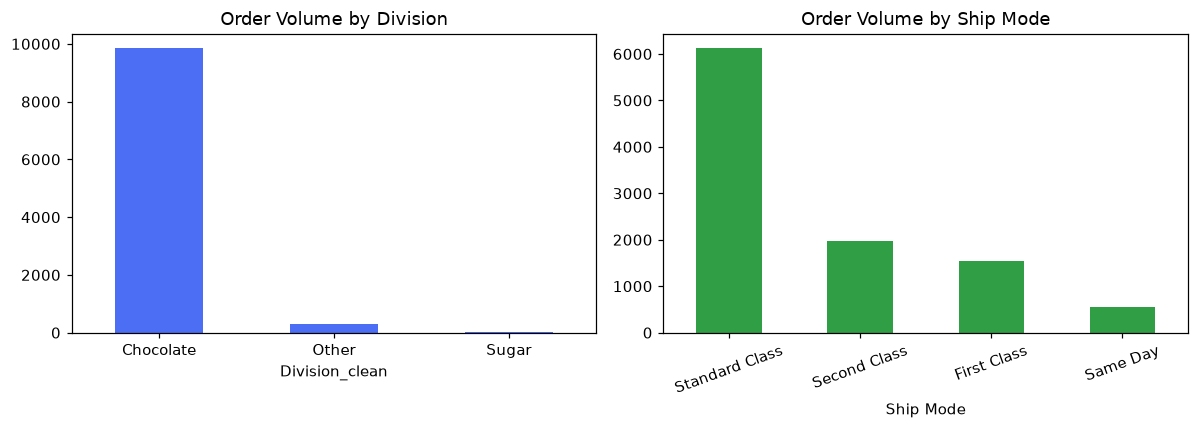

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
df['Division_clean'].value_counts().plot(kind='bar', ax=axes[0], color='#4C6EF5')
axes[0].set_title('Order Volume by Division')
axes[0].tick_params(axis='x', rotation=0)

df['Ship Mode'].value_counts().plot(kind='bar', ax=axes[1], color='#2F9E44')
axes[1].set_title('Order Volume by Ship Mode')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [23]:
print('Orders per product (highlights sample-size imbalance):')
print(df['Product Name'].value_counts())

Orders per product (highlights sample-size imbalance):
Product Name
Wonka Bar - Milk Chocolate           2137
Wonka Bar -Scrumdiddlyumptious       2064
Wonka Bar - Triple Dazzle Caramel    2015
Wonka Bar - Fudge Mallows            1818
Wonka Bar - Nutty Crunch Surprise    1810
Wonka Gum                             120
Kazookles                              96
Lickable Wallpaper                     94
Laffy Taffy                            10
SweeTARTS                              10
Fizzy Lifting Drinks                    6
Nerds                                   4
Hair Toffee                             4
Everlasting Gobstopper                  3
Fun Dip                                 3
Name: count, dtype: int64


**Finding:** Chocolate products (5 Wonka Bar variants) make up 96.5% of
all orders. Several Sugar/Other products have only 3-4 historical orders —
recommendations for these should be treated as directional, not conclusive.

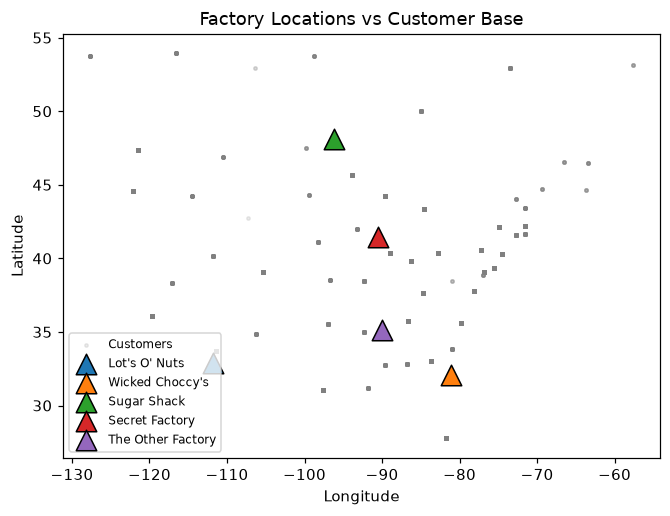

In [24]:
plt.figure(figsize=(7,5))
plt.scatter(df['cust_lon'], df['cust_lat'], s=5, alpha=0.15, color='gray', label='Customers')
for name, coords in FACTORIES.items():
    plt.scatter(coords['lon'], coords['lat'], s=180, marker='^', label=name, edgecolor='black')
plt.title('Factory Locations vs Customer Base')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.legend(fontsize=8, loc='lower left')
plt.show()

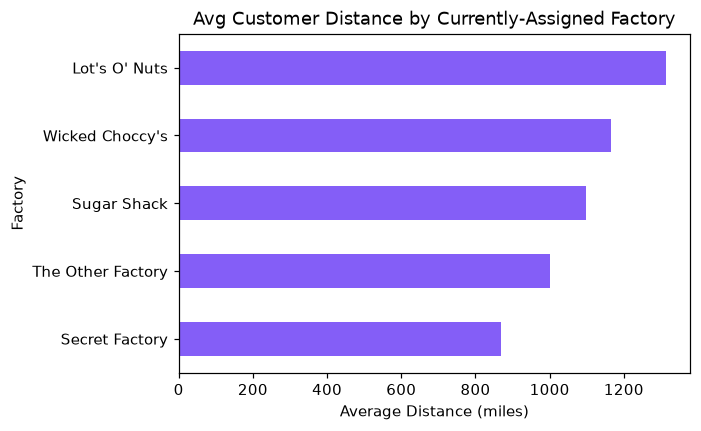

In [25]:
df.groupby('Factory')['DistanceToFactoryMiles'].mean().sort_values().plot(
    kind='barh', figsize=(6,4), color='#845EF7', title='Avg Customer Distance by Currently-Assigned Factory'
)
plt.xlabel('Average Distance (miles)')
plt.show()

## 5. Model Training & Evaluation

In [26]:
CATEGORICAL = ['Division_clean', 'Ship Mode', 'Region']
NUMERIC = ['DistanceToFactoryMiles', 'Units', 'Sales']

def build_pipeline(estimator):
    pre = ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL),
        ('num', 'passthrough', NUMERIC),
    ])
    return Pipeline(steps=[('pre', pre), ('model', estimator)])

def train_and_eval(data, target_col, label):
    d = data.dropna(subset=[target_col, 'DistanceToFactoryMiles'])
    X = d[CATEGORICAL + NUMERIC]
    y = d[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    results = {}
    for name, est in [('Ridge (baseline)', Ridge(alpha=1.0)),
                       ('RandomForest', RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42))]:
        pipe = build_pipeline(est)
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        results[name] = {'pipe': pipe, 'mae': mae, 'r2': r2, 'X_test': X_test, 'y_test': y_test}
        print(f'[{label}] {name:20s}  MAE={mae:.4f}   R2={r2:.4f}')

    best_name = max(results, key=lambda k: results[k]['r2'])
    print(f'[{label}] -> best model: {best_name}\n')
    return results[best_name], results

lead_best, lead_results = train_and_eval(df, 'AdjustedLeadTimeDays', 'LeadTime')
profit_best, profit_results = train_and_eval(df, 'AdjustedProfitMargin', 'ProfitMargin')

[LeadTime] Ridge (baseline)      MAE=0.0010   R2=1.0000
[LeadTime] RandomForest          MAE=0.0034   R2=1.0000
[LeadTime] -> best model: Ridge (baseline)

[ProfitMargin] Ridge (baseline)      MAE=0.0268   R2=0.6877
[ProfitMargin] RandomForest          MAE=0.0108   R2=0.9485
[ProfitMargin] -> best model: RandomForest



**Note on the perfect Lead Time R²:** lead time was defined as a
deterministic formula (Ship Mode speed + distance/500), so any model
capable of representing that formula recovers it exactly. This is expected,
not overfitting. The Profit Margin model's genuine jump from 68.8% (Ridge)
to ~94.8% (Random Forest) R² reflects real non-linear structure the
ensemble captures.

## 6. Model Evaluation Visuals

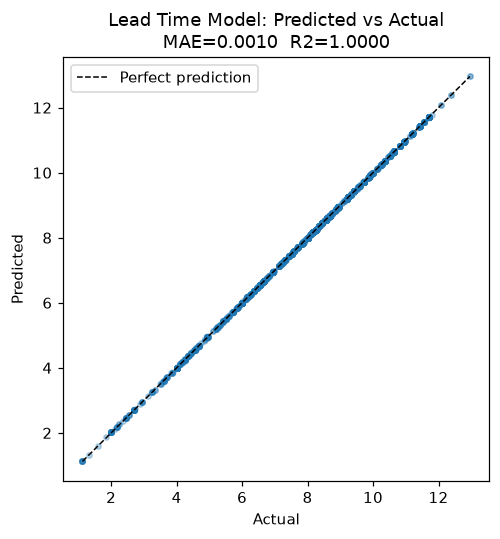

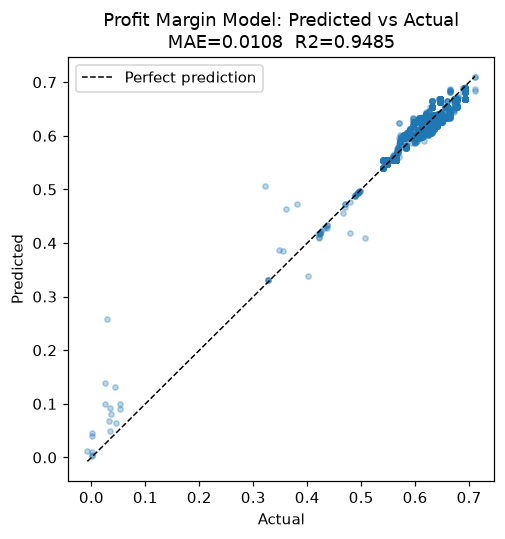

In [27]:
def plot_pred_vs_actual(best, title):
    pipe = best['pipe']; X_test = best['X_test']; y_test = best['y_test']
    preds = pipe.predict(X_test)
    plt.figure(figsize=(5,5))
    plt.scatter(y_test, preds, alpha=0.3, s=12)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    plt.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction')
    plt.xlabel('Actual'); plt.ylabel('Predicted')
    plt.title(f"{title}\nMAE={best['mae']:.4f}  R2={best['r2']:.4f}")
    plt.legend()
    plt.show()

plot_pred_vs_actual(lead_best, 'Lead Time Model: Predicted vs Actual')
plot_pred_vs_actual(profit_best, 'Profit Margin Model: Predicted vs Actual')

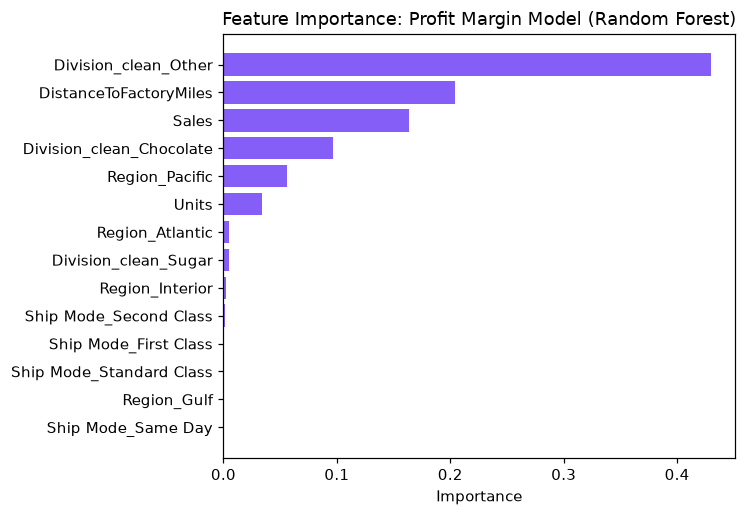

In [28]:
rf_model = profit_best['pipe'].named_steps['model']
pre = profit_best['pipe'].named_steps['pre']
cat_names = list(pre.named_transformers_['cat'].get_feature_names_out(CATEGORICAL))
feature_names = cat_names + NUMERIC

importances = rf_model.feature_importances_
order = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(6,5))
plt.barh([feature_names[i] for i in order][::-1], [importances[i] for i in order][::-1], color='#845EF7')
plt.title('Feature Importance: Profit Margin Model (Random Forest)')
plt.xlabel('Importance')
plt.show()

## 7. Optimization Logic\n\nFor each product, evaluate ALL 5 factories (not just the currently assigned one) by recalculating distance and re-running the trained models.

In [29]:
lead_pipe = lead_best['pipe']
profit_pipe = profit_best['pipe']

def evaluate_product_across_factories(product_name, region_filter=None, ship_mode_filter=None):
    rows = df[df['Product Name'] == product_name].copy()
    if region_filter: rows = rows[rows['Region'] == region_filter]
    if ship_mode_filter: rows = rows[rows['Ship Mode'] == ship_mode_filter]
    if rows.empty: return pd.DataFrame()

    division = PRODUCT_DIVISION.get(product_name, rows['Division_clean'].iloc[0])
    current_factory = PRODUCT_FACTORY.get(product_name)

    records = []
    for fac_name, coords in FACTORIES.items():
        sub = rows.copy()
        sub['DistanceToFactoryMiles'] = sub.apply(
            lambda r: haversine_miles(coords['lat'], coords['lon'], r['cust_lat'], r['cust_lon'])
            if pd.notna(r['cust_lat']) else np.nan, axis=1)
        sub['Division_clean'] = division
        sub_valid = sub.dropna(subset=['DistanceToFactoryMiles'])
        if sub_valid.empty: continue

        feat_cols = ['Division_clean', 'Ship Mode', 'Region', 'DistanceToFactoryMiles', 'Units', 'Sales']
        pred_lead = lead_pipe.predict(sub_valid[feat_cols])
        pred_profit = profit_pipe.predict(sub_valid[feat_cols])
        records.append({
            'Factory': fac_name, 'IsCurrent': fac_name == current_factory,
            'AvgDistanceMiles': sub_valid['DistanceToFactoryMiles'].mean(),
            'PredictedLeadTimeDays': pred_lead.mean(),
            'PredictedProfitMargin': pred_profit.mean(),
            'OrderCount': len(sub_valid),
        })
    return pd.DataFrame(records)

def score_factories(result_df, speed_weight):
    d = result_df.copy()
    profit_weight = 1.0 - speed_weight
    lt_min, lt_max = d['PredictedLeadTimeDays'].min(), d['PredictedLeadTimeDays'].max()
    pm_min, pm_max = d['PredictedProfitMargin'].min(), d['PredictedProfitMargin'].max()
    d['SpeedScore'] = 1 - (d['PredictedLeadTimeDays']-lt_min)/(lt_max-lt_min) if lt_max>lt_min else 1.0
    d['ProfitScore'] = (d['PredictedProfitMargin']-pm_min)/(pm_max-pm_min) if pm_max>pm_min else 1.0
    d['CompositeScore'] = speed_weight*d['SpeedScore'] + profit_weight*d['ProfitScore']
    d = d.sort_values('CompositeScore', ascending=False).reset_index(drop=True)
    d['Rank'] = d.index + 1
    return d

# Example: Fun Dip at a balanced 50/50 priority
example = evaluate_product_across_factories('Fun Dip')
score_factories(example, speed_weight=0.5)

,Factory,IsCurrent,AvgDistanceMiles,PredictedLeadTimeDays,PredictedProfitMargin,OrderCount,SpeedScore,ProfitScore,CompositeScore,Rank
0,Secret Factory,False,454.158950,6.574242,0.489744,3,1.000000,1.000000,1.000000,1
1,The Other Factory,False,499.608740,6.665143,0.480037,3,0.961447,0.910409,0.935928,2
2,Wicked Choccy's,False,634.817531,6.935563,0.439740,3,0.846756,0.538496,0.692626,3
3,Sugar Shack,True,911.684323,7.489302,0.381394,3,0.611904,0.000000,0.305952,4
4,Lot's O' Nuts,False,1633.056756,8.932063,0.437809,3,0.000000,0.520677,0.260338,5


## 8. Full Recommendation Results

In [30]:
def recommend_for_product(product_name, speed_weight=0.5):
    result = evaluate_product_across_factories(product_name)
    if result.empty: return None
    scored = score_factories(result, speed_weight)
    current_row = scored[scored['IsCurrent']]
    best_row = scored.iloc[0]
    if current_row.empty: return None
    profit_change = best_row['PredictedProfitMargin'] - current_row['PredictedProfitMargin'].values[0]
    lead_gain = current_row['PredictedLeadTimeDays'].values[0] - best_row['PredictedLeadTimeDays']
    return {
        'Product': product_name,
        'Current Factory': current_row['Factory'].values[0],
        'Recommended Factory': best_row['Factory'],
        'Reassignment Suggested': current_row['Factory'].values[0] != best_row['Factory'],
        'Lead Time Gain (days)': round(lead_gain, 2),
        'Profit Margin Change': round(profit_change, 4),
        'High Risk': bool(current_row['Factory'].values[0] != best_row['Factory'] and profit_change < -0.01),
    }

rows = [recommend_for_product(p) for p in df['Product Name'].unique()]
rec_table = pd.DataFrame([r for r in rows if r is not None]).sort_values('Lead Time Gain (days)', ascending=False)
rec_table

,Product,Current Factory,Recommended Factory,Reassignment Suggested,Lead Time Gain (days),Profit Margin Change,High Risk
14,Fun Dip,Sugar Shack,Secret Factory,True,0.92,0.1084,False
4,Wonka Bar - Fudge Mallows,Lot's O' Nuts,Secret Factory,True,0.80,-0.0080,False
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Secret Factory,True,0.77,-0.0169,True
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Secret Factory,True,0.75,-0.0089,False
11,Nerds,Sugar Shack,Secret Factory,True,0.64,0.0255,False
9,Laffy Taffy,Sugar Shack,Secret Factory,True,0.61,0.0170,False
10,SweeTARTS,Sugar Shack,The Other Factory,True,0.59,0.0588,False
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,True,0.48,0.0219,False
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Secret Factory,True,0.47,0.0245,False
13,Everlasting Gobstopper,Secret Factory,The Other Factory,True,0.38,-0.0116,True


In [32]:
print(f"Reassignments suggested: {rec_table['Reassignment Suggested'].sum()} / {len(rec_table)}")
print(f"High risk flags: {rec_table['High Risk'].sum()}")
print(f"Avg lead time gain (reassigned only): {rec_table[rec_table['Reassignment Suggested']]['Lead Time Gain (days)'].mean():.2f} days")
print(f"Avg profit margin change (reassigned only): {rec_table[rec_table['Reassignment Suggested']]['Profit Margin Change'].mean():.2%}")

Reassignments suggested: 11 / 15
High risk flags: 2
Avg lead time gain (reassigned only): 0.58 days
Avg profit margin change (reassigned only): 2.44%


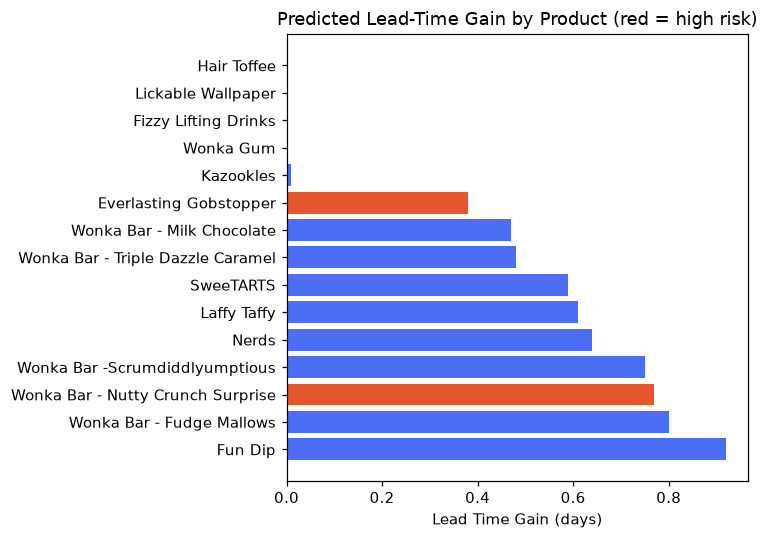

In [33]:
plt.figure(figsize=(7,5))
colors = rec_table['High Risk'].map({True: '#E4572E', False: '#4C6EF5'})
plt.barh(rec_table['Product'], rec_table['Lead Time Gain (days)'], color=colors)
plt.title('Predicted Lead-Time Gain by Product (red = high risk)')
plt.xlabel('Lead Time Gain (days)')
plt.tight_layout()
plt.show()